In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Task 1: Load & Explore Data

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding='latin1')

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   str    
 13  Product ID     9994 non-null   str    
 14  Category       9994 non-null   str    
 15  Sub-Category   9994 non-null   str    
 16  Product Name   9994 non-null   str    
 17  Sales          9994 non-null   float64
 18  Quantity       9994

In [5]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## Task 2: Data Cleaning

In [6]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [7]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub-Category   9994 non-null   s

## Task 3: Feature Engineering

In [9]:
df['Order Month'] = df['Order Date'].dt.month
df['Order Year'] = df['Order Date'].dt.year

In [10]:
df[['Order Date', 'Order Month', 'Order Year']].head()

,Order Date,Order Month,Order Year
0,2016-11-08,11,2016
1,2016-11-08,11,2016
2,2016-06-12,6,2016
3,2015-10-11,10,2015
4,2015-10-11,10,2015


In [11]:
df['Profit Ratio'] = df['Profit'] / df['Sales']

In [12]:
df[['Sales', 'Profit', 'Profit Ratio']].head()

,Sales,Profit,Profit Ratio
0,261.9600,41.9136,0.1600
1,731.9400,219.5820,0.3000
2,14.6200,6.8714,0.4700
3,957.5775,-383.0310,-0.4000
4,22.3680,2.5164,0.1125


## Task 4: GroupBy & Aggregation

In [13]:
sales_by_category = df.groupby('Category')['Sales'].sum()
print(sales_by_category)

Category
Furniture          741999.7953
Office Supplies    719047.0320
Technology         836154.0330
Name: Sales, dtype: float64


Technology is the highest revenue-generating category, indicating strong customer demand. Office Supplies generate the least revenue, suggesting lower-priced or lower-demand products. However, further analysis of profit is required to determine true performance.

In [14]:
df.groupby('Category')['Profit'].sum()

Category
Furniture           18451.2728
Office Supplies    122490.8008
Technology         145454.9481
Name: Profit, dtype: float64

## Insight: Category Performance Analysis (Sales vs Profit)

From the analysis of total sales and profit by category, we observe a clear imbalance between revenue generation and profitability.

### 🔹 Technology
Technology is the strongest category in terms of both sales and profit. It leads in revenue generation and also produces the highest profit, indicating a healthy and efficient business segment. This suggests strong demand, good pricing strategy, and efficient cost structure.

### 🔹 Office Supplies
Office Supplies show a unique pattern: despite having the lowest total sales, they generate relatively high profit. This indicates strong profit margins and cost efficiency. It suggests that this category is highly profitable relative to its size and may benefit from increased focus or expansion.

### 🔹 Furniture
Furniture presents a concern. Although it has high total sales, it produces the lowest profit among all categories. This indicates low profitability margins, likely due to high costs, discounts, or operational inefficiencies. This category may require strategic review to improve profitability.

### Overall Conclusion
The analysis reveals that high sales do not always translate into high profit. Technology is the most balanced and strongest category, Office Supplies are highly efficient in profit generation, while Furniture requires attention due to its low profitability despite strong sales performance.

In [15]:
profit_by_region = df.groupby('Region')['Profit'].sum()
print(profit_by_region)

Region
Central     39706.3625
East        91522.7800
South       46749.4303
West       108418.4489
Name: Profit, dtype: float64


## Insight: Profit Distribution Across Regions

The analysis of profit across regions reveals a clear geographical imbalance in performance.

### 🔹 West Region
The West region generates the highest profit, making it the strongest market for the business. This indicates strong demand, efficient operations, or favorable market conditions.

### 🔹 East Region
The East region also performs strongly, contributing significantly to overall profit. It closely follows the West region, making it another key revenue driver.

### 🔹 South Region
The South region shows moderate performance but significantly lower profit compared to the top regions. This suggests potential inefficiencies or weaker market demand.

### 🔹 Central Region
The Central region is the weakest performer in terms of profit. This indicates possible challenges such as low demand, high operational costs, or aggressive discounting.

### Overall Conclusion
There is a clear imbalance in regional performance, with West and East driving most of the profit while South and Central lag behind. This suggests a need for targeted regional strategies to improve underperforming areas.

In [16]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False).head()
print(top_customers)

Customer Name
Sean Miller      25043.050
Tamara Chand     19052.218
Raymond Buch     15117.339
Tom Ashbrook     14595.620
Adrian Barton    14473.571
Name: Sales, dtype: float64


In [17]:
df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False).head()

Customer Name
Tamara Chand     8981.3239
Raymond Buch     6976.0959
Sanjit Chand     5757.4119
Hunter Lopez     5622.4292
Adrian Barton    5444.8055
Name: Profit, dtype: float64

##  Insight: Customer Value Analysis (Sales vs Profit)

A combined analysis of customer sales and profit reveals important differences between revenue contribution and actual profitability.

### 🔹 Top Overall Customer: Tamara Chand
Tamara Chand stands out as the most valuable customer, ranking highly in both sales and profit. This indicates strong purchasing behavior combined with high profitability.

### 🔹 High Sales but Lower Profit: Sean Miller
Sean Miller is the highest sales-generating customer but does not appear in the top profit contributors. This suggests that despite high purchase volume, the profit margin from this customer is relatively lower.

### 🔹 Balanced Customers: Raymond Buch
Raymond Buch performs strongly in both sales and profit, indicating a stable and high-value customer profile.

###  Key Insight
Sales alone do not define customer value. Profit analysis reveals the true economic contribution of each customer. Businesses should focus not only on high-spending customers but also on high-profit customers for long-term sustainability.

In [18]:
monthly_sales = df.groupby(['Order Year', 'Order Month'])['Sales'].sum()
print(monthly_sales)

Order Year  Order Month
2014        1               14236.8950
            2                4519.8920
            3               55691.0090
            4               28295.3450
            5               23648.2870
            6               34595.1276
            7               33946.3930
            8               27909.4685
            9               81777.3508
            10              31453.3930
            11              78628.7167
            12              69545.6205
2015        1               18174.0756
            2               11951.4110
            3               38726.2520
            4               34195.2085
            5               30131.6865
            6               24797.2920
            7               28765.3250
            8               36898.3322
            9               64595.9180
            10              31404.9235
            11              75972.5635
            12              74919.5212
2016        1               18542.4910
 

##  Insight: Monthly Sales Trend Analysis

The monthly sales data from 2014 to 2017 shows a strong upward growth trend, indicating continuous business expansion over time.

### 🔹 Yearly Growth
Sales consistently increase year over year, with 2017 showing the highest overall performance. This suggests successful business scaling and increased market demand.

### 🔹 Seasonal Pattern
A clear seasonal pattern is observed across all years. Sales consistently peak during September, November, and December, while early-year months such as January and February show relatively lower performance.

###  Key Conclusion
The business demonstrates both strong long-term growth and predictable seasonal behavior. End-of-year months represent the most critical sales period and should be prioritized for marketing and inventory planning.

## Task 5: Pivot Tables

In [19]:
pivot1 = pd.pivot_table(df, values='Sales', index='Category', columns='Region', aggfunc='sum')
print(pivot1)

Region               Central        East       South         West
Category                                                         
Furniture        163797.1638  208291.204  117298.684  252612.7435
Office Supplies  167026.4150  205516.055  125651.313  220853.2490
Technology       170416.3120  264973.981  148771.908  251991.8320


##  Insight: Category vs Region Sales Analysis

The pivot table reveals how sales are distributed across product categories and regions.

### 🔹 Technology Dominance
Technology consistently performs strongly across all regions, particularly in the East and West, where it records the highest sales figures. This indicates strong demand for technology products regardless of location.

### 🔹 Regional Performance Differences
The East and West regions are the strongest overall contributors to sales across all categories. In contrast, the South region consistently shows the lowest sales across Furniture, Office Supplies, and Technology, indicating weaker market performance.

### 🔹 Furniture Performance
Furniture shows relatively uneven performance, with particularly low sales in the South region compared to other areas.

###  Key Conclusion
Regional performance plays a major role in overall sales distribution. East and West regions drive the majority of revenue, while the South region represents an area of underperformance across all product categories.

In [20]:
pivot2 = pd.pivot_table(df, values='Sales', index='Order Month', columns='Segment', aggfunc='sum')
print(pivot2)

Segment         Consumer    Corporate  Home Office
Order Month                                       
1             50441.2906   26790.3480   17693.1970
2             33826.1760   14575.0670   11350.0084
3             89174.7070   58239.9132   57590.8686
4             54845.1895   49233.1636   33683.7755
5             86932.7144   47289.0323   20807.0650
6             82910.1803   40858.5370   28949.9620
7             81769.7730   46919.2060   18549.1180
8             82319.8063   57529.4477   19194.8090
9            185055.9196   74020.2213   48573.8048
10            66713.0877   78291.7600   55318.1370
11           170958.7383  119431.3957   62070.9370
12           176453.7623   92968.2750   55871.4662


##  Insight: Segment Sales Behavior Over Time

The analysis of sales by customer segment over time reveals clear differences in purchasing behavior and contribution.

### 🔹 Consumer Segment Dominance
The Consumer segment is the primary driver of sales across all months, consistently outperforming Corporate and Home Office segments. It also shows the strongest seasonal spikes, particularly in September, November, and December.

### 🔹 Corporate Segment Stability
The Corporate segment shows moderate but stable performance throughout the year. While it does not reach the same peak levels as Consumers, it maintains consistent contribution, especially during high-demand months.

### 🔹 Home Office Underperformance
The Home Office segment consistently records the lowest sales across all months, indicating weaker demand or smaller customer base compared to other segments.

###  Key Conclusion
Sales behavior is strongly influenced by customer segment, with Consumers driving the majority of revenue. Additionally, all segments follow a similar seasonal pattern, with significant peaks toward the end of the year.

In [21]:
pivot3 = pd.pivot_table(df, values='Profit', index='Sub-Category', aggfunc='sum')
print(pivot3)

                  Profit
Sub-Category            
Accessories   41936.6357
Appliances    18138.0054
Art            6527.7870
Binders       30221.7633
Bookcases     -3472.5560
Chairs        26590.1663
Copiers       55617.8249
Envelopes      6964.1767
Fasteners       949.5182
Furnishings   13059.1436
Labels         5546.2540
Machines       3384.7569
Paper         34053.5693
Phones        44515.7306
Storage       21278.8264
Supplies      -1189.0995
Tables       -17725.4811


##  Insight: Profit Analysis by Sub-Category

The analysis of profit by sub-category reveals significant variation in profitability across different product types.

### 🔹 Highly Profitable Sub-Categories
Copiers, Phones, Accessories, and Paper generate the highest profits. These categories are key revenue drivers and indicate strong market demand combined with healthy profit margins.

### 🔹 Low Profit or Loss-Making Sub-Categories
Certain sub-categories, such as Tables and Bookcases, generate negative profit, indicating losses. Supplies also show slight negative performance.

###  Key Insight
The analysis clearly shows that not all high-sales products are profitable. Some categories generate strong revenue but still result in losses due to cost structures or discounting strategies.

###  Business Implication
The company should consider reviewing pricing, cost structure, or discount strategies for loss-making sub-categories, especially Tables and Bookcases, to improve overall profitability.

## Task 6: Data Splitting & Merging

In [22]:
df1 = df[['Customer ID', 'Customer Name', 'Region']]
df2 = df[['Customer ID', 'Sales', 'Profit']]

In [23]:
merged_df = pd.merge(df1, df2, on='Customer ID')

In [24]:
merged_df.head()

,Customer ID,Customer Name,Region,Sales,Profit
0,CG-12520,Claire Gute,South,261.960,41.9136
1,CG-12520,Claire Gute,South,731.940,219.5820
2,CG-12520,Claire Gute,South,18.160,1.8160
3,CG-12520,Claire Gute,South,131.376,-95.2476
4,CG-12520,Claire Gute,South,5.344,1.8704


## Task 7: Data Visualization

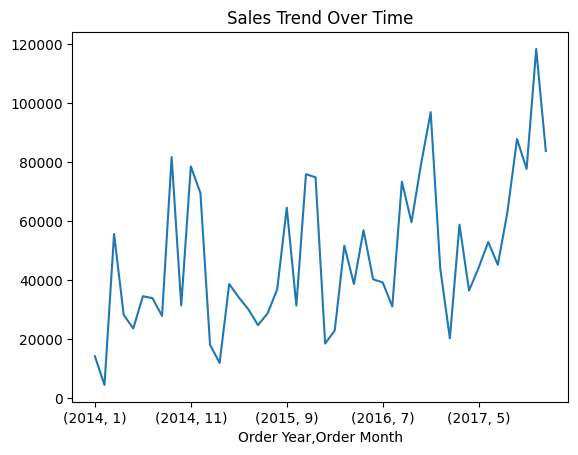

In [25]:
monthly_sales.plot()
plt.title("Sales Trend Over Time")
plt.show()

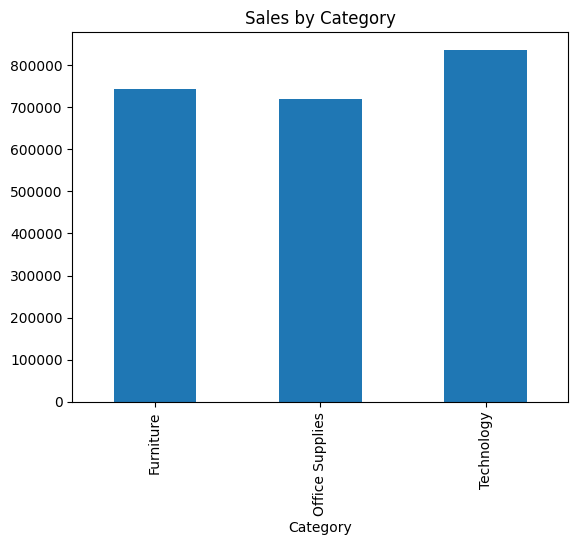

In [26]:
sales_by_category.plot(kind='bar')
plt.title("Sales by Category")
plt.show()

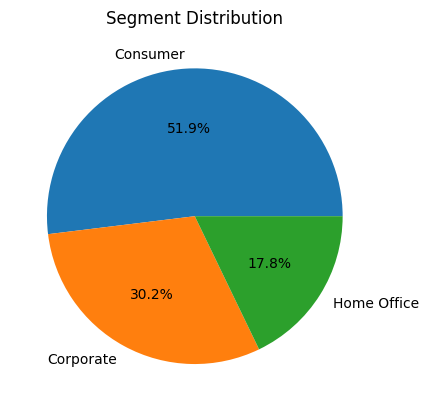

In [27]:
df['Segment'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Segment Distribution")
plt.show()